In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("Mall_Customers.csv")

In [3]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

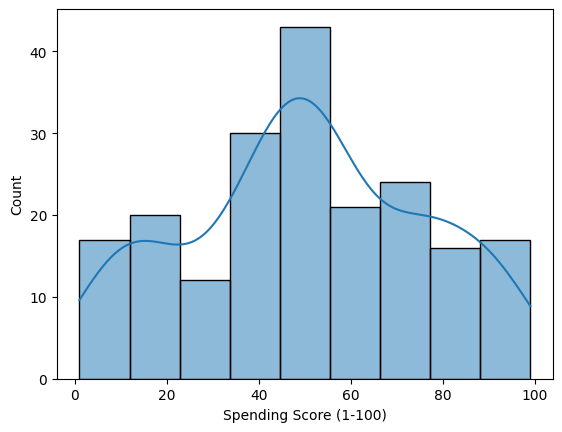

In [9]:
sns.histplot(data, x='Spending Score (1-100)', kde=True)

In [10]:
df = data.drop('CustomerID', axis=1)

df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


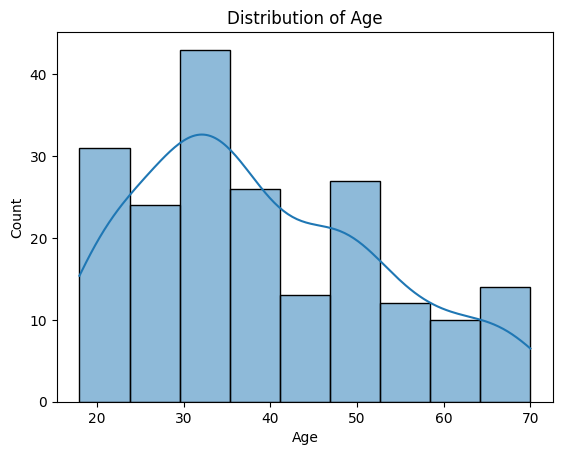

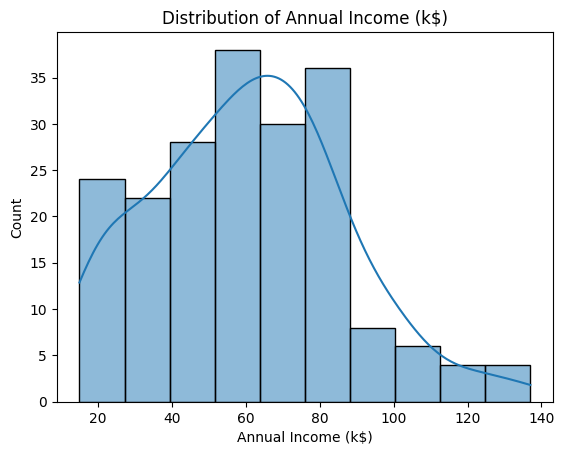

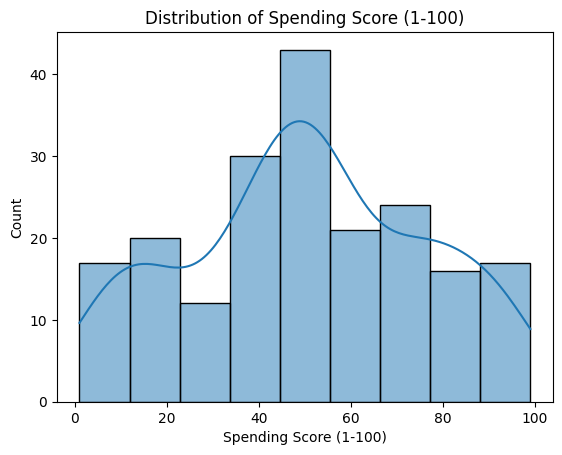

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in cols:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

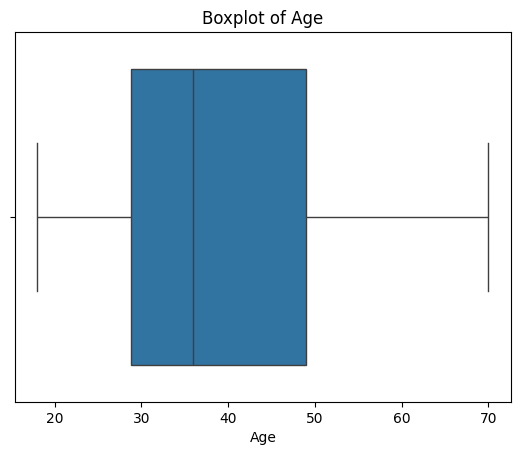

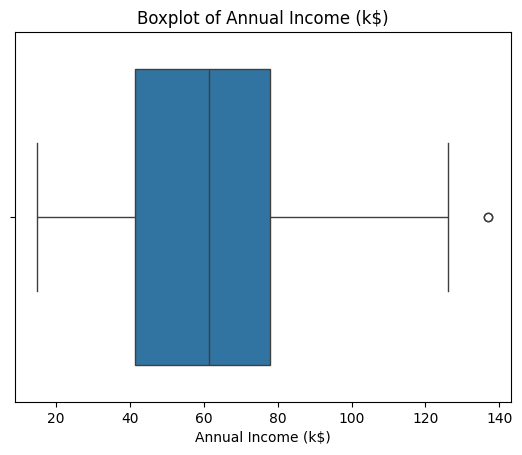

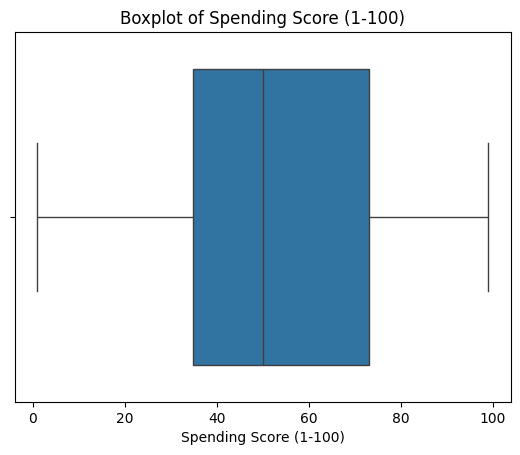

In [12]:
for col in cols:
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

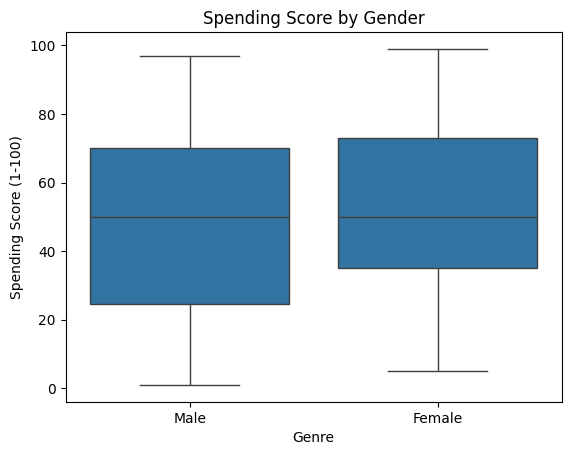

In [13]:
sns.boxplot(x='Genre', y='Spending Score (1-100)', data=data)
plt.title('Spending Score by Gender')
plt.show()

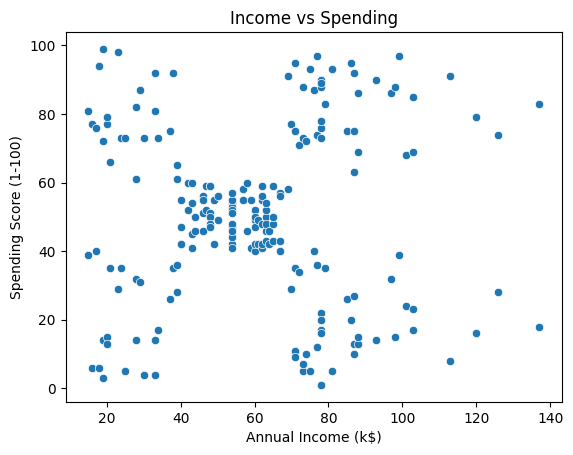

In [14]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=data)
plt.title('Income vs Spending')
plt.show()

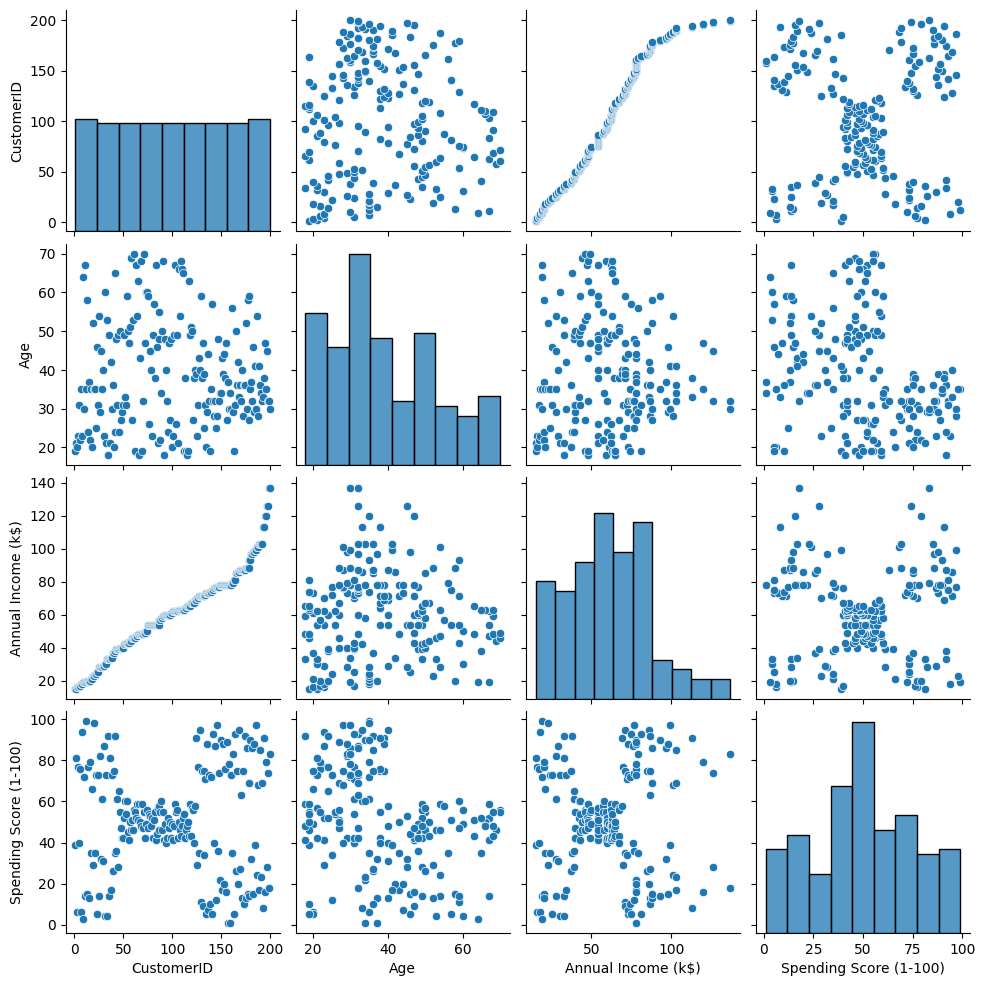

In [15]:
sns.pairplot(data)

In [16]:
X = df.copy()

In [17]:
df['Spending_Efficiency'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

In [18]:
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 100], labels=[0,1,2,3])

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

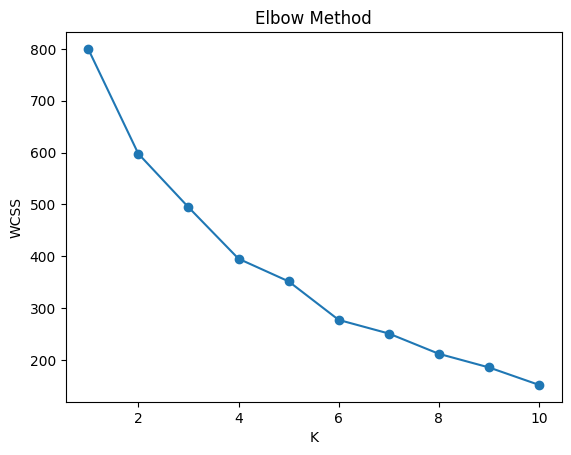

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [24]:
df['Cluster'].value_counts()

Cluster
3    64
0    60
2    42
1    34
Name: count, dtype: int64

In [26]:
df.groupby('Cluster').mean(numeric_only=True)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Spending_Efficiency
Cluster,,,,,
0,0.566667,54.700000,46.900000,39.933333,0.835553
1,0.411765,41.264706,88.500000,16.764706,0.189871
2,0.000000,28.690476,60.904762,70.238095,1.509964
3,1.000000,29.375000,58.296875,64.437500,1.464086
